# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import joblib
import json
import shap
import mlflow
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
from optuna.importance import get_param_importances
from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
    RANDOM_SEED,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    get_format,
    optuna_cv_results_to_df,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-26 22:08:21.580 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 5
TEST_SIZE = 0.2
FIRST_ITER_TRIALS = 50
SECOND_ITER_TRIALS = 200
FS_VALID_SIZE = 0.2
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    *USELESS_FEATURES,
]

MODEL_NAME = "lightgbm_optuna_39"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

mlflow.set_experiment(f"{MODEL_NAME}_v01")

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [5]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [6]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=4,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    window_test_size=39,
)
print_best_params(study)

[I 2026-01-26 22:08:26,345] A new study created in memory with name: no-name-8e2a877d-02fe-4f24-b31a-139e15cad0e8
[I 2026-01-26 22:10:27,549] Trial 1 finished with value: 0.9849436634665063 and parameters: {'max_depth': 3, 'learning_rate': 0.11969313903485523, 'n_estimators': 728, 'subsample': 0.8312988204297977, 'colsample_bytree': 0.9183592556474343, 'min_child_samples': 21, 'reg_alpha': 0.01487131352311989, 'reg_lambda': 0.10026145034148395, 'num_leaves_3': 4}. Best is trial 1 with value: 0.9849436634665063.
[I 2026-01-26 22:11:20,241] Trial 0 finished with value: 0.9850888294649598 and parameters: {'max_depth': 5, 'learning_rate': 0.040783682768741066, 'n_estimators': 484, 'subsample': 0.9608545735201759, 'colsample_bytree': 0.7910871460881883, 'min_child_samples': 19, 'reg_alpha': 0.00267562119703835, 'reg_lambda': 0.00015450414395776495, 'num_leaves_5': 18}. Best is trial 1 with value: 0.9849436634665063.
[I 2026-01-26 22:12:41,966] Trial 2 finished with value: 0.976562890572404 

Best parameters: {'max_depth': 4, 'learning_rate': 0.012164045005925252, 'n_estimators': 807, 'subsample': 0.5509263049818879, 'colsample_bytree': 0.9689578050880369, 'min_child_samples': 22, 'reg_alpha': 0.00047722959396684567, 'reg_lambda': 3.1852187937223375, 'num_leaves_4': 9}
Best score: 0.97283


In [7]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
49,"{'max_depth': 4, 'learning_rate': 0.0121640450...",0.140894,0.972835,-1.012242,-0.894634,-0.872378,-0.852988,-1.231933,1
38,"{'max_depth': 5, 'learning_rate': 0.0166348989...",0.141233,0.974209,-1.025409,-0.894267,-0.871162,-0.851134,-1.229072,2
48,"{'max_depth': 4, 'learning_rate': 0.0123965363...",0.139938,0.974442,-1.014588,-0.897948,-0.873080,-0.855289,-1.231304,3
35,"{'max_depth': 4, 'learning_rate': 0.0139888448...",0.141020,0.974635,-1.016539,-0.898607,-0.872850,-0.852456,-1.232723,4
44,"{'max_depth': 4, 'learning_rate': 0.0127224790...",0.140338,0.974734,-1.011832,-0.898231,-0.873274,-0.856712,-1.233620,5


### SHAP feature selection

In [8]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [9]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=4,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
    window_test_size=39,
)
print_best_params(study)

[I 2026-01-26 22:48:18,683] A new study created in memory with name: no-name-6459e26e-f67c-4858-af47-6f614578b156
[I 2026-01-26 22:49:52,182] Trial 5 finished with value: 0.9690028582486097 and parameters: {'max_depth': 5, 'learning_rate': 0.10471492707768004, 'n_estimators': 175, 'subsample': 0.6834526651533048, 'colsample_bytree': 0.5560823376044741, 'min_child_samples': 12, 'reg_alpha': 0.0030163368609303566, 'reg_lambda': 0.4881089302944679, 'num_leaves_5': 19, 'keep_count': 26}. Best is trial 5 with value: 0.9690028582486097.
[I 2026-01-26 22:50:33,808] Trial 0 finished with value: 0.9683394379564738 and parameters: {'max_depth': 5, 'learning_rate': 0.01187719929412565, 'n_estimators': 681, 'subsample': 0.9880667692261681, 'colsample_bytree': 0.5757506357421833, 'min_child_samples': 22, 'reg_alpha': 0.05671843011222775, 'reg_lambda': 0.00030484541300506785, 'num_leaves_5': 26, 'keep_count': 32}. Best is trial 0 with value: 0.9683394379564738.
[I 2026-01-26 22:50:45,962] Trial 3 fi

Best parameters: {'max_depth': 3, 'learning_rate': 0.07202912475563542, 'n_estimators': 572, 'subsample': 0.5505423955839629, 'colsample_bytree': 0.9770021604697021, 'min_child_samples': 24, 'reg_alpha': 0.2422800581455577, 'reg_lambda': 1.1836940513955703, 'num_leaves_3': 5, 'keep_count': 16}
Best score: 0.95179


In [10]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
182,"{'max_depth': 3, 'learning_rate': 0.0720291247...",0.135982,0.951788,-0.973754,-0.858479,-0.868220,-0.849959,-1.208526,1
27,"{'max_depth': 3, 'learning_rate': 0.1543922927...",0.133587,0.952343,-0.974921,-0.861438,-0.867501,-0.853536,-1.204321,2
110,"{'max_depth': 3, 'learning_rate': 0.1303048145...",0.136106,0.952647,-0.985257,-0.864918,-0.866418,-0.841058,-1.205584,3
153,"{'max_depth': 3, 'learning_rate': 0.0683558720...",0.135560,0.952813,-0.969621,-0.860223,-0.867238,-0.856452,-1.210531,4
64,"{'max_depth': 3, 'learning_rate': 0.2314974082...",0.134174,0.952894,-0.972770,-0.860749,-0.870315,-0.853799,-1.206839,5


### Scores

In [11]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")

Train set metrics:
RMSLE: 0.8623
MAE:  6.8573


In [12]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 90/90 [01:14<00:00,  1.20it/s]


In [13]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")


Test set metrics:
RMSLE: 0.8404
MAE:  7.1113


## Graphs

### Optuna importances

In [14]:
get_param_importances(study)

{'keep_count': np.float64(0.6946656696571012),
 'learning_rate': np.float64(0.06879214487231301),
 'reg_alpha': np.float64(0.06677430043371561),
 'n_estimators': np.float64(0.06179456047900716),
 'subsample': np.float64(0.06128911689763037),
 'min_child_samples': np.float64(0.02149643004683945),
 'colsample_bytree': np.float64(0.01826743644381349),
 'reg_lambda': np.float64(0.005157105467595242),
 'max_depth': np.float64(0.0017632357019846964)}

## SHAP explanation

In [53]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

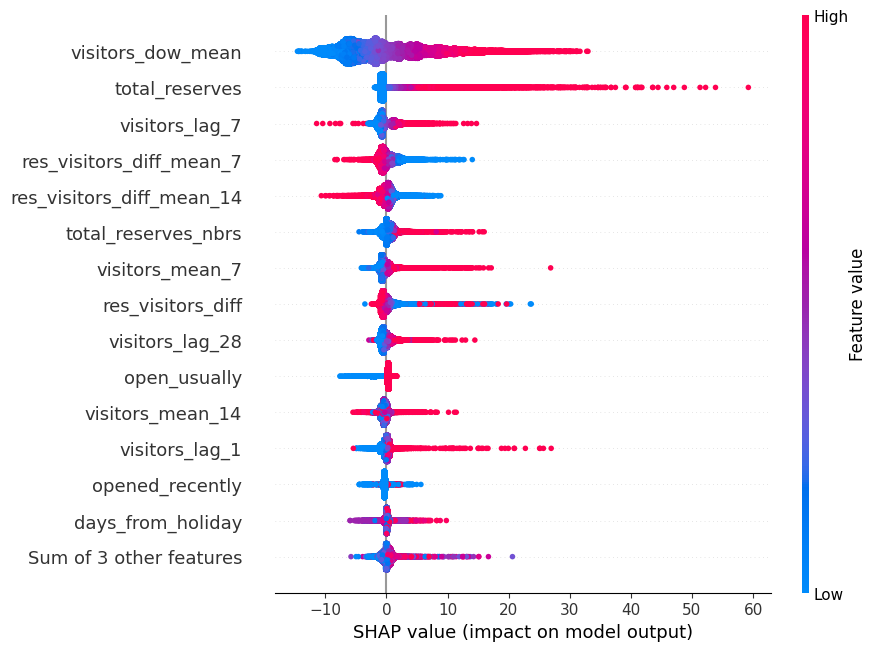

In [54]:
shap.plots.beeswarm(shap_values, max_display=15)

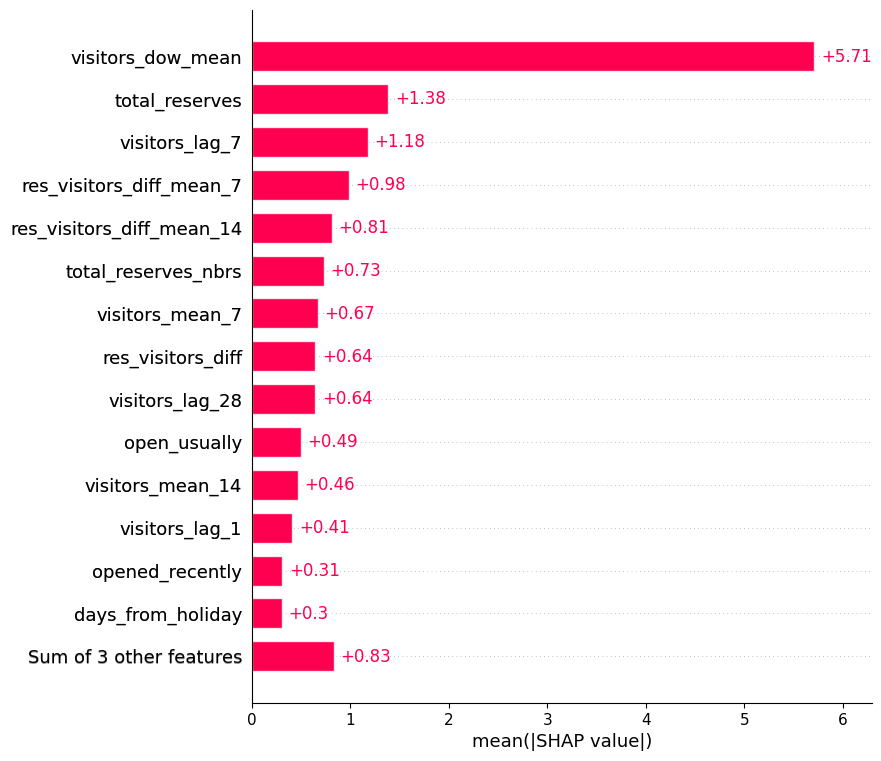

In [55]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

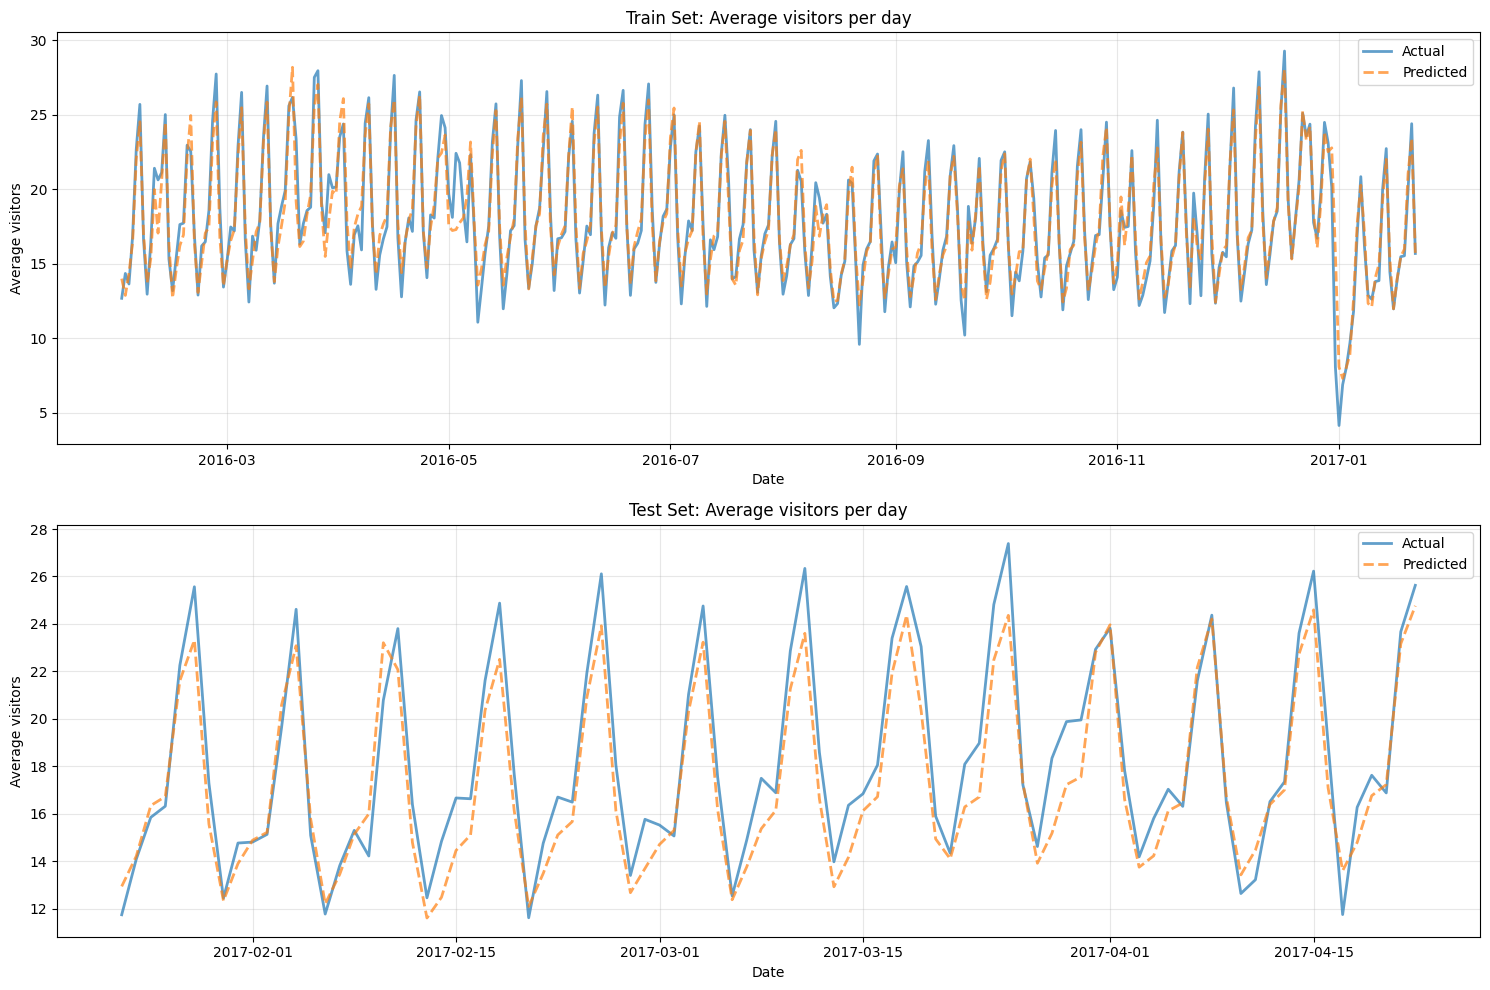

In [56]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [5]:
model_shap = joblib.load(MODEL_PATH)

In [57]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)
test_features = test_features.reset_index(drop=True)

In [58]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 39/39 [00:32<00:00,  1.19it/s]


In [59]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [61]:
joblib.dump(model_shap, MODEL_PATH)
params_to_save = {
    "cv_splits": CV_SPLITS,
    "test_size": TEST_SIZE,
    "feature_selection_validation_size": FS_VALID_SIZE,
    "first_iteration_n_trials": FIRST_ITER_TRIALS,
    "second_iteration_n_trials": SECOND_ITER_TRIALS,
    "test_score": test_rmsle,
    "cv result": cv_results.sort_values(["rank_test_score"]).iloc[0].to_dict(),
}

PARAMS_PATH = MODELS_DIR / f"{MODEL_NAME}_params.json"
with open(PARAMS_PATH, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)